<a href="https://colab.research.google.com/github/sabovicveljko/Monte-Carlo-Portfolio-Optimisation/blob/main/MCPO_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Environment Setup

In [1]:
#!pip install yfinance --upgrade

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
print("Success: Libraries imported and environment is ready.")

Success: Libraries imported and environment is ready.


# Step 2: Data Acquisition
In this step, we define our portfolio assets and download 10 years of historical data.

In [2]:
tickers = ['AAPL', 'NVDA', 'AMD', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NIO', 'JPM', 'BAC', 'V', 'KO', 'PEP', 'XOM', 'JNJ', 'PFE', 'WMT', 'PG', 'NKE', 'GLD']
start_date = '2016-05-01'
end_date = '2026-05-01'
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
data = raw_data['Close']

print("\nSuccess: Historical data downloaded.")
data.head()

[*********************100%***********************]  20 of 20 completed


Success: Historical data downloaded.


Ticker,AAPL,AMD,AMZN,BAC,GLD,GOOGL,JNJ,JPM,KO,MSFT,NIO,NKE,NVDA,PEP,PFE,PG,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2016-05-02,21.1881,3.7400,34.1925,11.8414,123.2400,35.4277,85.6396,48.8898,32.8790,44.5312,NaN,52.2381,0.8813,76.3782,19.7598,61.6412,16.1200,72.9930,18.8423,57.6538
2016-05-03,21.5366,3.6000,33.5660,11.5127,122.9600,35.1316,85.5941,47.9471,32.7766,43.8009,NaN,52.1767,0.8708,76.4742,20.3020,61.7402,15.4880,71.8115,18.6778,56.9940
2016-05-04,21.3126,3.6000,33.5450,11.3283,122.2100,35.2769,85.2371,47.1883,32.8790,43.8801,NaN,51.8173,0.8509,76.8139,20.1212,62.1208,14.8373,71.6999,18.7307,56.8840
2016-05-05,21.2260,3.6600,32.9545,11.2641,122.0700,35.4426,85.7384,46.9354,32.9375,43.9417,NaN,51.0108,0.8561,76.9542,20.2237,61.8924,14.1020,71.9697,18.7363,56.9487
2016-05-06,21.1077,3.6800,33.6975,11.3122,123.1800,35.9618,85.6320,47.2113,33.1275,44.3376,NaN,51.2212,0.8649,77.5080,20.2297,62.5243,14.3287,72.3046,19.0263,57.2527


# Step 3: Data Cleaning and Preprocessing
Handling missing values and ensuring data integrity.

In [3]:
print("Missing values count per asset:")
print(data.isnull().sum())

data = data.ffill().dropna()
print(f"\nSuccess: Data cleaned. Final dataset shape: {data.shape}")

Missing values count per asset:
Ticker
AAPL       0
AMD        0
AMZN       0
BAC        0
GLD        0
GOOGL      0
JNJ        0
JPM        0
KO         0
MSFT       0
NIO      596
NKE        0
NVDA       0
PEP        0
PFE        0
PG         0
TSLA       0
V          0
WMT        0
XOM        0
dtype: int64

Success: Data cleaned. Final dataset shape: (1918, 20)


# Step 4: Financial Metrics Calculation
Calculating daily returns, annualized mean returns, and the covariance matrix.

In [4]:
daily_returns = data.pct_change().dropna()
annual_mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

print("Success: Returns and Covariance matrix calculated.")
print("\nAnnualized Mean Returns:")
print(annual_mean_returns)

Success: Returns and Covariance matrix calculated.

Annualized Mean Returns:
Ticker
AAPL     0.2649
AMD      0.4705
AMZN     0.1898
BAC      0.1507
GLD      0.1871
GOOGL    0.2981
JNJ      0.1121
JPM      0.2053
KO       0.1208
MSFT     0.2217
NIO      0.3507
NKE     -0.0088
NVDA     0.5821
PEP      0.0960
PFE      0.0250
PG       0.1221
TSLA     0.5940
V        0.1482
WMT      0.2255
XOM      0.1739
dtype: float64


# Step 5: Portfolio Performance Logic
Defining a function to calculate the return and volatility for a given set of weights.

In [5]:
def portfolio_performance(weights, annual_mean_returns, cov_matrix):
    returns = np.sum(annual_mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

print("Success: Performance function is ready for Monte Carlo simulation.")

Success: Performance function is ready for Monte Carlo simulation.


# Step 6: Monte Carlo Simulation -- P1
In this step, we make a function that simulates n random portfolio weight allocations
and computes the expected return, volatility, and Sharpe ratio for each.

In [34]:
np.random.seed(2026) # Rerun this cell before every simulation to get the same independent results

In [7]:
# Monte Carlo parameters
num_portfolios1 = 1000
num_portfolios2 = 50000
num_portfolios_final= 100000
risk_free_rate = 0.045 # around the average for us treasury bonds in the last 10 years

# Monte Carlo simulation
def monte_carlo_simulation(num_portfolios, annual_mean_returns, cov_matrix, risk_free_rate):

    loc_num_assets = len(annual_mean_returns)

    # Storage arrays
    mc_returns = np.zeros(num_portfolios)
    mc_volatility = np.zeros(num_portfolios)
    mc_sharpe = np.zeros(num_portfolios)

    # Store portfolio weights
    mc_weights = np.zeros((num_portfolios, loc_num_assets))

    for i in range(num_portfolios):

        # Generate random weights
        weights = np.random.random(loc_num_assets)

        # Normalize weights so they sum to 1
        weights /= np.sum(weights)

        # Store weights
        mc_weights[i] = weights

        # Portfolio performance
        portfolio_return, portfolio_std_dev = portfolio_performance(
            weights,
            annual_mean_returns,
            cov_matrix
        )

        # Store results
        mc_returns[i] = portfolio_return
        mc_volatility[i] = portfolio_std_dev

        # Sharpe ratio
        mc_sharpe[i] = (
            portfolio_return - risk_free_rate
        ) / portfolio_std_dev

    return mc_returns, mc_volatility, mc_sharpe, mc_weights

In [33]:
mc_returns1, mc_volatility1, mc_sharpe1, mc_weights1 = monte_carlo_simulation(
    num_portfolios1,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [28]:
mc_returns2, mc_volatility2, mc_sharpe2, mc_weights2 = monte_carlo_simulation(
    num_portfolios2,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [35]:
mc_returns, mc_volatility, mc_sharpe, mc_weights = monte_carlo_simulation(
    num_portfolios_final,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [11]:
def get_best(mc_returns, mc_volatility, mc_sharpe, mc_weights):

    max_sharpe_idx = np.argmax(mc_sharpe)
    min_var_idx = np.argmin(mc_volatility)

    return {
        "max_sharpe_return": mc_returns[max_sharpe_idx],
        "max_sharpe_vol": mc_volatility[max_sharpe_idx],
        "max_sharpe_ratio": mc_sharpe[max_sharpe_idx],
        "max_sharpe_weights": mc_weights[max_sharpe_idx],

        "min_var_return": mc_returns[min_var_idx],
        "min_var_vol": mc_volatility[min_var_idx],
        "min_var_weights": mc_weights[min_var_idx]
    }

In [36]:
res1 = get_best(mc_returns1, mc_volatility1, mc_sharpe1, mc_weights1)
res2 = get_best(mc_returns2, mc_volatility2, mc_sharpe2, mc_weights2)
res3 = get_best(mc_returns, mc_volatility, mc_sharpe, mc_weights)

In [37]:
comparison = pd.DataFrame([
    {
        "Simulations": "1k",
        "Max Sharpe": res1["max_sharpe_ratio"],
        "Return": res1["max_sharpe_return"],
        "Volatility": res1["max_sharpe_vol"]
    },
    {
        "Simulations": "50k",
        "Max Sharpe": res2["max_sharpe_ratio"],
        "Return": res2["max_sharpe_return"],
        "Volatility": res2["max_sharpe_vol"]
    },
    {
        "Simulations": "100k",
        "Max Sharpe": res3["max_sharpe_ratio"],
        "Return": res3["max_sharpe_return"],
        "Volatility": res3["max_sharpe_vol"]
    }
])

print(comparison)

  Simulations  Max Sharpe  Return  Volatility
0          1k      1.0753  0.2886      0.2266
1         50k      1.1176  0.2797      0.2100
2        100k      1.1176  0.2797      0.2100


In [38]:
mc_df = pd.DataFrame({
    'Return': mc_returns,
    'Volatility': mc_volatility,
    'Sharpe': mc_sharpe
})

Let's see how should we invest 10 000 EUR if we were to listen to this simulation.

In [15]:
investment = 10000

In [39]:
max_idx = np.argmax(mc_sharpe)

mc_best_weights = mc_weights[max_idx]

In [40]:
portfolio_allocation_by_mc = pd.DataFrame({
    "Stock": tickers,
    "Weight": mc_best_weights,
    "Amount (€)": mc_best_weights * investment
})

print(portfolio_allocation_by_mc.sort_values("Weight", ascending=False))

    Stock  Weight  Amount (€)
4   GOOGL  0.1518   1518.2508
16    WMT  0.1346   1345.7448
6    TSLA  0.1054   1053.8008
0    AAPL  0.0912    912.1532
5    AMZN  0.0854    853.5580
12    PEP  0.0611    610.9405
1    NVDA  0.0508    507.6046
19    GLD  0.0490    490.3802
3    MSFT  0.0475    475.2080
13    XOM  0.0433    433.4527
18    NKE  0.0368    367.5419
14    JNJ  0.0332    332.1262
17     PG  0.0259    259.4923
9     BAC  0.0199    199.1014
7     NIO  0.0188    188.1081
8     JPM  0.0171    170.6732
10      V  0.0136    136.2986
2     AMD  0.0110    110.4413
15    PFE  0.0035     34.7350
11     KO  0.0000      0.3888


Let's see how the safest mc portfolio performed and how safe is it.

In [41]:
min_vol_idx = np.argmin(mc_volatility)

In [42]:
min_vol_weights = mc_weights[min_vol_idx]
min_vol_return = mc_returns[min_vol_idx]
min_vol = mc_volatility[min_vol_idx]
min_vol_sharpe = mc_sharpe[min_vol_idx]

In [43]:
print(f"Min Volatility → Return: {min_vol_return:.2%}, Volatility: {min_vol:.2%}, Sharpe: {min_vol_sharpe:.4f}")

Min Volatility → Return: 16.10%, Volatility: 15.31%, Sharpe: 0.7576


# Step 7: Gradient-Based Optimisation -- P2
Using scipy.optimize.minimize (SLSQP) to find the exact
minimum-variance and maximum-Sharpe portfolios, and comparing
them against the Monte Carlo simulation envelope.

In [21]:
#!pip install scipy
from scipy.optimize import minimize
num_assets = len(annual_mean_returns)

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_weights = np.ones(num_assets) / num_assets

# Minimum Variance
def min_variance(weights):
    return portfolio_performance(weights, annual_mean_returns, cov_matrix)[1]

result_minvar = minimize(min_variance, init_weights,
                         method='SLSQP', bounds=bounds, constraints=constraints)
minvar_ret, minvar_vol = portfolio_performance(result_minvar.x, annual_mean_returns, cov_matrix)
minvar_sharpe = (minvar_ret - risk_free_rate) / minvar_vol

# Maximum Sharpe
def neg_sharpe(weights):
    ret, vol = portfolio_performance(weights, annual_mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol

result_maxsharpe = minimize(neg_sharpe, init_weights,
                            method='SLSQP', bounds=bounds, constraints=constraints)
maxsh_ret, maxsh_vol = portfolio_performance(result_maxsharpe.x, annual_mean_returns, cov_matrix)
maxsh_sharpe = (maxsh_ret - risk_free_rate) / maxsh_vol

print(f"Min Variance → Return: {minvar_ret:.2%}, Volatility: {minvar_vol:.2%}, Sharpe: {minvar_sharpe:.4f}")
print(f"Max Sharpe   → Return: {maxsh_ret:.2%},  Volatility: {maxsh_vol:.2%}, Sharpe: {maxsh_sharpe:.4f}")

Min Variance → Return: 16.16%, Volatility: 11.90%, Sharpe: 0.9800
Max Sharpe   → Return: 28.37%,  Volatility: 16.45%, Sharpe: 1.4508


Let's see how should we invest 10 000 EUR if we were to listen to the optimization.

In [22]:
opt_weights = result_maxsharpe.x
opt_weights[np.abs(opt_weights) < 1e-4] = 0


In [23]:
portfolio_allocation_by_opt = pd.DataFrame({
    "Stock": tickers,
    "Weight": opt_weights,
    "Amount (€)": opt_weights * investment
})

print(portfolio_allocation_by_opt.sort_values("Weight", ascending=False))

    Stock  Weight  Amount (€)
4   GOOGL  0.4713   4712.6325
18    NKE  0.2603   2602.5266
12    PEP  0.1390   1389.7708
16    WMT  0.0729    728.8307
19    GLD  0.0283    283.4716
5    AMZN  0.0205    205.0979
7     NIO  0.0078     77.6699
0    AAPL  0.0000      0.0000
3    MSFT  0.0000      0.0000
2     AMD  0.0000      0.0000
1    NVDA  0.0000      0.0000
6    TSLA  0.0000      0.0000
11     KO  0.0000      0.0000
10      V  0.0000      0.0000
9     BAC  0.0000      0.0000
8     JPM  0.0000      0.0000
15    PFE  0.0000      0.0000
14    JNJ  0.0000      0.0000
13    XOM  0.0000      0.0000
17     PG  0.0000      0.0000


# Step 8: Efficient Frontier Visualisation -- P3
Plotting all 100,000 simulated portfolios, marking the optimal
portfolios found by scipy, and drawing the Capital Market Line
using the risk-free rate.

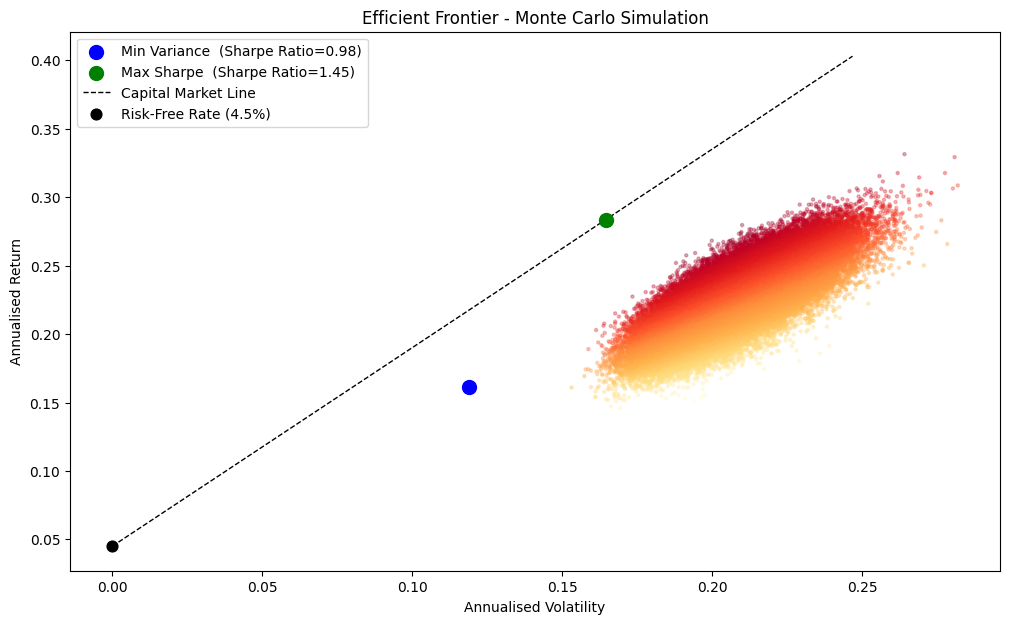

In [44]:
plt.figure(figsize=(12, 7))

# Monte Carlo cloud (The 50.000 portfolio's annualised performance // Each dot represents a portfolio)
plt.scatter(mc_df['Volatility'], mc_df['Return'],
            c=mc_df['Sharpe'], cmap='YlOrRd',
            alpha=0.3, s=5)

# Min Variance portfolio (Lowest risk portfolio // Ignores return on risk)
plt.scatter(minvar_vol, minvar_ret, marker='o', color='blue',
            s=100, zorder=5, label=f'Min Variance  (Sharpe Ratio={minvar_sharpe:.2f})')

# Max Sharpe portfolio (Best risk to return ratio portfolio)
plt.scatter(maxsh_vol, maxsh_ret, marker='o', color='green',
            s=100, zorder=5, label=f'Max Sharpe  (Sharpe Ratio={maxsh_sharpe:.2f})')

# Capital Market Line (Connects Risk free point to Max sharpe point)
cml_x = np.linspace(0, maxsh_vol * 1.5, 100)
cml_y = risk_free_rate + maxsh_sharpe * cml_x
plt.plot(cml_x, cml_y, 'k--', linewidth=1, label='Capital Market Line')

# Risk-free rate point (US bonds rate // 0 risk - low return investment)
plt.scatter(0, risk_free_rate, marker='o', color='black',
            s=60, zorder=5, label=f'Risk-Free Rate ({risk_free_rate:.1%})')

plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Return')
plt.title('Efficient Frontier - Monte Carlo Simulation')
plt.legend()
plt.show()

# Step 9: Impact of the Risk-Free Asset

## Observations

The inclusion of a risk-free asset significantly changes the structure of the efficient frontier. Without a risk-free asset, investors are restricted to portfolios composed entirely of risky assets located along the curved Markowitz efficient frontier. Once a risk-free asset is introduced, investors can combine the risk-free asset with the tangency portfolio (the maximum Sharpe ratio portfolio).

This combination forms the Capital Market Line (CML), representing the portfolios with the highest expected return for each level of risk.

Key properties of the CML include:

The line begins at the risk-free rate on the y-axis, where portfolio volatility equals zero.
The line passes through the tangency portfolio corresponding to the maximum Sharpe ratio.
Portfolios located on the CML dominate portfolios below the line by offering either:
higher expected return for the same level of risk, or
lower risk for the same expected return.

The addition of a risk-free asset therefore improves the attainable risk-return trade-off available to investors.

## Monte Carlo Convergence

The comparison between 1,000, 50,000, and 100,000 Monte Carlo simulations demonstrated that increasing the number of simulated portfolios improves the stability and quality of the efficient frontier approximation.

The results showed that:

1,000 simulations produced a noisier and less stable estimate of the optimal portfolio.
50,000 and 100,000 simulations produced nearly identical results, indicating convergence of the Monte Carlo approximation.
Additional simulations beyond 50,000 resulted in only marginal improvements.

This suggests that approximately 50,000 simulations were sufficient to capture the overall shape of the efficient frontier for the selected asset universe.

## Key Takeaway

Without a risk-free asset → investors are limited to the curved frontier.  
With a risk-free asset → investors can reach any point on the CML by mixing
the tangency portfolio with cash, achieving a **better risk-return tradeoff**
than any purely risky portfolio below the line.

## scipy vs Monte Carlo Comparison

The Monte Carlo simulation and the scipy optimizer produced broadly consistent results, but important differences remained between the two approaches.

The Monte Carlo simulation identified a diversified maximum Sharpe portfolio distributed across many assets, while the gradient-based optimizer produced a significantly more concentrated allocation focused primarily on a small subset of stocks. This occurred because the optimizer directly solves the constrained optimization problem and therefore converges toward a mathematically optimal corner solution, whereas Monte Carlo relies on random sampling and approximates the efficient frontier.

The optimizer achieved a substantially higher Sharpe ratio than the best portfolio identified through Monte Carlo simulation, indicating that random sampling did not fully reach the true optimum even with 100,000 simulated portfolios.

Overall:

Monte Carlo simulation provided strong visualization and intuition regarding the opportunity set and diversification structure of feasible portfolios.
The scipy optimizer delivered a more precise estimate of the optimal portfolio allocation and risk-return trade-off.

Together, the two methods complement each other by combining intuitive frontier exploration with exact numerical optimization.